In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.colors as mcolors

In [2]:
df = pd.read_excel("p2optica.xlsx", sheet_name="h2input")

In [3]:
df["theta_1_rel"] = df['theta '] - df['ref']
df["theta_2_rel"] = df['theta_2'] - df['ref']
df["theta_avg"] = df[["theta_1_rel", "theta_2_rel"]].mean(axis=1, skipna=True)

cteRed = 606.9
cteRedDelta = 29.9

df["wl"] = np.sin( df["theta_avg"] * np.pi / 180 ) / (cteRed * df["m"] * 1000) * 10**9

In [4]:
colores = {
    "VioletaOscuro": "violeta oscuro",
    "Violeta": "violeta",
    "Perryelornitorrinco": "perrryelornitorrinco",
    "Teal": "teal",
    "VerdeFuerte": "verdefuerte",
    "VerdeFlojo": "verdeflojo",
    "Naranja": "naranja",
    "Rojo": "rojo",
    "RojoOscuro": "rojo oscuro"
}

dfColores = {nombre: df[df["color"] == valor] for nombre, valor in colores.items()}

'''coloresEscritos = [
    "violeta",
    "violeta oscuro",
    "perryelornitorrinco",
    "teal",
    "verde fuerte",
    "verdeflojo",
    "naranja",
    "rojo",
    "rojooscuro"
]

coloresNombrados = [
    "violeta",
    "violetaoscuro",
    "perryelornitorrinco",
    "teal",
    "verde fuerte",
    "verdeflojo",
    "naranja",
    "rojo",
    "rojooscuro"
]'''

'coloresEscritos = [\n    "violeta",\n    "violeta oscuro",\n    "perryelornitorrinco",\n    "teal",\n    "verde fuerte",\n    "verdeflojo",\n    "naranja",\n    "rojo",\n    "rojooscuro"\n]\n\ncoloresNombrados = [\n    "violeta",\n    "violetaoscuro",\n    "perryelornitorrinco",\n    "teal",\n    "verde fuerte",\n    "verdeflojo",\n    "naranja",\n    "rojo",\n    "rojooscuro"\n]'

In [5]:
medias = {}

for color, dfi in dfColores.items():
    medias[color] = np.mean(dfi["wl"])

In [6]:
display(medias)

{'VioletaOscuro': np.float64(439.0913991349158),
 'Violeta': np.float64(445.57876039090127),
 'Perryelornitorrinco': np.float64(470.82128983335184),
 'Teal': np.float64(490.12331686499317),
 'VerdeFuerte': np.float64(500.8374474557609),
 'VerdeFlojo': np.float64(502.0529412438209),
 'Naranja': np.float64(587.3219572033903),
 'Rojo': np.float64(666.5614973723849),
 'RojoOscuro': np.float64(704.1627926441261)}

In [7]:
def wavelength_to_rgba(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    Additionally alpha value set to 0.5 outside range
    '''
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 750:
        A = 1.
    else:
        A = 0.5
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B, A)


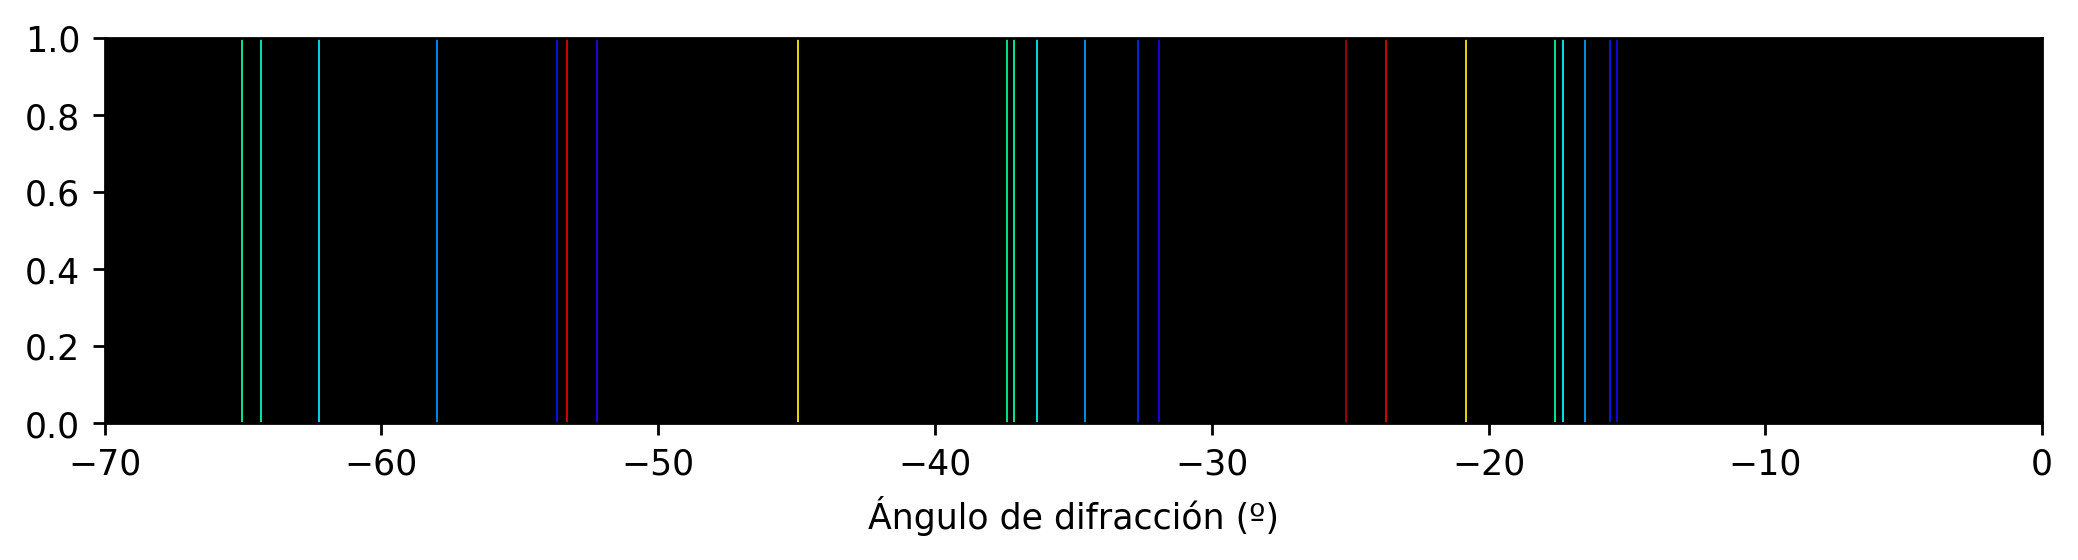

In [8]:
fig, ax = plt.subplots(dpi = 250, figsize=(10, 2))

wavelengths = wavelengths = df["wl"].to_numpy()
angles = df['theta_avg'].to_numpy().copy()
angles[angles > 180] -= 360


colorArray = []
for wavelength in wavelengths:
    colorArray.append(wavelength_to_rgba(wavelength))

ax.set_facecolor("black")

ax.vlines(angles, ymin=0, ymax=1, color = colorArray, lw = 0.5)

ax.set_xlabel("Ángulo de difracción (º)")

ax.set_ylim(0,1)
ax.set_xlim(-70,0)

plt.savefig("colorineschuliguays.png", dpi = 250)
plt.show()


stuff below

In [9]:

'''dVioletaOscuro = df[df["color"] == "violeta oscuro"]
dVioleta = df[df["color"] == "violeta"]
dPerryelornitorrinco = df[df["color"] == "perryelornitorrinco"]
dTeal = df[df["color"] == "teal"]
dVerdeFuerte = df[df["color"] == "verdefuerte"]
dVerdeFlojo = df[df["color"] == "verdeflojo"]
dNaranja = df[df["color"] == "naranja"]
dRojo = df[df["color"] == "rojo"]
dRojoOscuro = df[df["color"] == "rojooscuro"]'''


'dVioletaOscuro = df[df["color"] == "violeta oscuro"]\ndVioleta = df[df["color"] == "violeta"]\ndPerryelornitorrinco = df[df["color"] == "perryelornitorrinco"]\ndTeal = df[df["color"] == "teal"]\ndVerdeFuerte = df[df["color"] == "verdefuerte"]\ndVerdeFlojo = df[df["color"] == "verdeflojo"]\ndNaranja = df[df["color"] == "naranja"]\ndRojo = df[df["color"] == "rojo"]\ndRojoOscuro = df[df["color"] == "rojooscuro"]'

In [10]:
'''medias = {}
for nombre, dfi in dfs.items():
    filtro = (dfi["m"] == 1) | (dfi["m"] == -1)
    medias[nombre] = np.nanmean(dfi[filtro]["theta_avg"] * np.sign(dfi[filtro]["m"]))


#mediaVioletaOscuro = np.average(dVioletaOscuro[(dVioletaOscuro["m"] == 1) | (dVioletaOscuro["m"] == -1)]['theta_avg'] * np.sign(dVioletaOscuro[(dVioletaOscuro["m"] == 1) | (dVioletaOscuro["m"] == -1)]['m']))

'''

'medias = {}\nfor nombre, dfi in dfs.items():\n    filtro = (dfi["m"] == 1) | (dfi["m"] == -1)\n    medias[nombre] = np.nanmean(dfi[filtro]["theta_avg"] * np.sign(dfi[filtro]["m"]))\n\n\n#mediaVioletaOscuro = np.average(dVioletaOscuro[(dVioletaOscuro["m"] == 1) | (dVioletaOscuro["m"] == -1)][\'theta_avg\'] * np.sign(dVioletaOscuro[(dVioletaOscuro["m"] == 1) | (dVioletaOscuro["m"] == -1)][\'m\']))\n\n'

In [11]:
'''def plot_diffraction_spectrum(
    wavelengths_nm,
    intensities,
    orders,
    grating_spacing_m,
    line_width=2.0,
    line_height=1.0,
    angle_unit="deg",
    title="Diffraction Spectrum",
    min_alpha=0.05,
    use_intensity_for_height=False,
):
    """
    Plot spectral lines in diffraction-angle space on a black background.

    Parameters
    ----------
    wavelengths_nm : array-like
        Wavelengths in nm.
    intensities : array-like
        Intensities correlated with wavelengths.
    orders : array-like
        Diffraction orders correlated with wavelengths.
    grating_spacing_m : float
        Grating spacing in meters.
    line_width : float
        Thickness of the vertical lines.
    line_height : float
        Maximum line height.
    angle_unit : str
        "deg" or "rad".
    title : str
        Plot title.
    min_alpha : float
        Minimum visible alpha after intensity normalization.
    use_intensity_for_height : bool
        If True, line height is also scaled by intensity.
    """
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    intensities = np.asarray(intensities, dtype=float)
    orders = np.asarray(orders, dtype=float)

    if not (len(wavelengths_nm) == len(intensities) == len(orders)):
        raise ValueError("wavelengths_nm, intensities, and orders must have the same length.")

    # Convert wavelengths to meters
    wavelengths_m = wavelengths_nm * 1e-9

    # Grating equation: m * lambda = d * sin(theta)
    argument = orders * wavelengths_m / grating_spacing_m

    # Keep only physically valid diffraction lines
    valid = np.abs(argument) <= 1.0

    wavelengths_nm = wavelengths_nm[valid]
    intensities = intensities[valid]
    orders = orders[valid]
    argument = argument[valid]

    # Compute diffraction angle
    theta = np.arcsin(argument)

    if angle_unit == "deg":
        x = np.degrees(theta)
        xlabel = "Diffraction angle (degrees)"
    elif angle_unit == "rad":
        x = theta
        xlabel = "Diffraction angle (radians)"
    else:
        raise ValueError("angle_unit must be 'deg' or 'rad'.")

    # Normalize intensity -> alpha
    if len(intensities) == 0:
        alphas = np.array([])
        heights = np.array([])
    elif np.max(intensities) == np.min(intensities):
        # all intensities identical
        alphas = np.ones_like(intensities)
        heights = np.full_like(intensities, line_height, dtype=float)
    else:
        norm = (intensities - np.min(intensities)) / (np.max(intensities) - np.min(intensities))
        alphas = min_alpha + (1.0 - min_alpha) * norm
        heights = (0.1 + 0.9 * norm) * line_height

    # Figure / axes
    fig, ax = plt.subplots(figsize=(12, 4), facecolor="black")
    ax.set_facecolor("black")

    # Draw one vertical line per spectral line
    for angle, wl, alpha, h in zip(x, wavelengths_nm, alphas, heights):
        # Your function gives (R, G, B, A_from_wavelength)
        r, g, b, _ = wavelength_to_rgba(wl)

        # Replace alpha with intensity-based alpha
        rgba = (r, g, b, alpha)

        ymax = h if use_intensity_for_height else line_height

        ax.vlines(
            angle,
            ymin=0,
            ymax=ymax,
            colors=[rgba],
            linewidth=line_width
        )

    # Styling for black background
    ax.set_facecolor("black")
    ax.set_xlabel(xlabel, color="white")
    ax.set_ylabel("Intensity display", color="white")
    ax.set_title(title, color="white")

    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("white")

    # Limits
    if len(x) > 0:
        xmin, xmax = np.min(x), np.max(x)
        pad = 0.05 * max(xmax - xmin, 1e-9)
        ax.set_xlim(xmin - pad, xmax + pad)

    ax.set_ylim(0, line_height * 1.05)

    plt.tight_layout()
    plt.show()'''

'def plot_diffraction_spectrum(\n    wavelengths_nm,\n    intensities,\n    orders,\n    grating_spacing_m,\n    line_width=2.0,\n    line_height=1.0,\n    angle_unit="deg",\n    title="Diffraction Spectrum",\n    min_alpha=0.05,\n    use_intensity_for_height=False,\n):\n    """\n    Plot spectral lines in diffraction-angle space on a black background.\n\n    Parameters\n    ----------\n    wavelengths_nm : array-like\n        Wavelengths in nm.\n    intensities : array-like\n        Intensities correlated with wavelengths.\n    orders : array-like\n        Diffraction orders correlated with wavelengths.\n    grating_spacing_m : float\n        Grating spacing in meters.\n    line_width : float\n        Thickness of the vertical lines.\n    line_height : float\n        Maximum line height.\n    angle_unit : str\n        "deg" or "rad".\n    title : str\n        Plot title.\n    min_alpha : float\n        Minimum visible alpha after intensity normalization.\n    use_intensity_for_height 

In [12]:
'''# Example data
wavelengths = df["wl"].to_numpy()
intensities = [1 for i in range(len(wavelengths))]
orders = df["m"].to_numpy()

# Example grating: 600 lines/mm
d = 1 / (cteRed*10**3)   # meters

plot_diffraction_spectrum(
    wavelengths_nm=wavelengths,
    intensities=intensities,
    orders=orders,
    grating_spacing_m=d,
    line_width=3.0,
    line_height=1.0,
    angle_unit="deg",
    title="Emission Spectrum",
    min_alpha=0.08,
    use_intensity_for_height=False,   # set True if you want height to scale too
)'''

'# Example data\nwavelengths = df["wl"].to_numpy()\nintensities = [1 for i in range(len(wavelengths))]\norders = df["m"].to_numpy()\n\n# Example grating: 600 lines/mm\nd = 1 / (cteRed*10**3)   # meters\n\nplot_diffraction_spectrum(\n    wavelengths_nm=wavelengths,\n    intensities=intensities,\n    orders=orders,\n    grating_spacing_m=d,\n    line_width=3.0,\n    line_height=1.0,\n    angle_unit="deg",\n    title="Emission Spectrum",\n    min_alpha=0.08,\n    use_intensity_for_height=False,   # set True if you want height to scale too\n)'